In [1]:
from yahoo_oauth import OAuth2
from datetime import datetime, timedelta
import yahoo_fantasy_api as yfa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from pybaseball import playerid_lookup, statcast_batter, batting_stats
import unicodedata, re, time, os
from matplotlib.backends.backend_pdf import PdfPages

# -------------------- CONFIG --------------------
LEAGUE_KEY = '458.l.76357'
TEAM_KEY   = '458.l.76357.t.1'
#TEAM_KEY   = '458.l.76357.t.10' #Adam
START_DATE = '2025-03-27'
END_DATE   = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')  # yesterday
DAYS_BACK_FOR_PLOT = 75
SLEEP_BETWEEN_CALLS = 0.4  # seconds, be gentle to APIs

USE_CAREER_AVG = True      # set False to skip FanGraphs pull
CAREER_START_YEAR = 2000   # inclusive
CAREER_END_YEAR   = datetime.today().year

SAVE_PLOTS = True
PLOTS_DIR  = 'plots'
EXPORT_PDF = True
PDF_PATH   = 'plots/roster_batting_plots.pdf'

In [2]:
def normalize_name(s: str) -> str:
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    return re.sub(r'\s+', ' ', s).strip()

SUFFIXES = {"jr", "jr.", "sr", "sr.", "ii", "iii", "iv", "v"}

def split_first_last(fullname: str):
    parts = normalize_name(fullname).split()
    if parts and parts[-1].lower().rstrip(".") in SUFFIXES and len(parts) >= 3:
        parts = parts[:-1]
    first = parts[0] if parts else ""
    last  = " ".join(parts[1:]) if len(parts) > 1 else ""
    return first, last

def is_batter_item(p: dict) -> bool:
    if 'position_type' in p and p['position_type'] is not None:
        return p['position_type'] == 'B'
    pos = set(p.get('eligible_positions', []))
    return bool(pos & {'C','1B','2B','3B','SS','LF','CF','RF','OF','IF','MI','CI','UTIL'})

def safe_lookup_ids(first: str, last: str):
    """Return MLBAM and FanGraphs IDs (ints) or (None, None)."""
    if not last:
        return None, None
    df = playerid_lookup(last, first, fuzzy=True)
    if df is None or df.empty:
        return None, None
    df = df[df['key_mlbam'].notna()].copy()
    if df.empty:
        return None, None
    for c in ['mlb_played_last','mlb_played_first']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.sort_values(['mlb_played_last','mlb_played_first'], ascending=[False, True])
    row = df.iloc[0]
    mlbam = int(row['key_mlbam']) if pd.notnull(row['key_mlbam']) else None
    idfg  = int(row['key_fangraphs']) if 'key_fangraphs' in row and pd.notnull(row['key_fangraphs']) else None
    return mlbam, idfg

def rate_stats(sum_row: pd.Series | dict):
    H   = sum_row['H']
    AB  = sum_row['AB']
    BB  = sum_row.get('BB', 0)
    HBP = sum_row.get('HBP', 0)
    SF  = sum_row.get('SF', 0)
    TB  = sum_row.get('TB', 0)
    denom_obp = AB + BB + HBP + SF
    AVG = (H/AB) if AB > 0 else np.nan
    OBP = ((H+BB+HBP)/denom_obp) if denom_obp > 0 else np.nan
    SLG = (TB/AB) if AB > 0 else np.nan
    OPS = (OBP + SLG) if np.isfinite(OBP) and np.isfinite(SLG) else np.nan
    return AVG, OBP, SLG, OPS

In [3]:
sc = OAuth2(None, None, from_file='oauth2.json')
gm = yfa.Game(sc, 'mlb')
_ = gm.league_ids(year=CAREER_END_YEAR)  # ensures auth context is valid
lg = gm.to_league(LEAGUE_KEY)

tm = lg.to_team(TEAM_KEY)

teams = lg.teams()
team_name = teams[TEAM_KEY]['name']

roster = tm.roster()  # current/default roster; tm.roster(week) for a specific period
#print(roster)

[2025-08-25 19:33:40,314 DEBUG] [yahoo_oauth.oauth.__init__] Checking 
[2025-08-25 19:33:40,315 DEBUG] [yahoo_oauth.oauth.token_is_valid] ELAPSED TIME : 274.62838983535767
[2025-08-25 19:33:40,315 DEBUG] [yahoo_oauth.oauth.token_is_valid] TOKEN IS STILL VALID


In [4]:
if SAVE_PLOTS and not os.path.isdir(PLOTS_DIR):
    os.makedirs(PLOTS_DIR, exist_ok=True)

all_frames = []
id_map_rows = []
for p in roster:
    # resolve player name string from Yahoo object
    if isinstance(p.get('name'), dict) and 'full' in p['name']:
        full_name = p['name']['full']
    else:
        full_name = p.get('name') or p.get('display_name') or ""
    if not full_name or not is_batter_item(p):
        continue

    print(full_name)
    first, last = split_first_last(full_name)
    mlbam, idfg = safe_lookup_ids(first, last)
    id_map_rows.append({'player_name': full_name, 'mlbam': mlbam, 'IDfg': idfg})

    if not mlbam:
        print(f"[WARN] No MLBAM for {full_name} — skipping Statcast")
        continue

    try:
        df = statcast_batter(START_DATE, END_DATE, mlbam)
        if df is None or df.empty:
            print(f"[INFO] No Statcast rows for {full_name} ({mlbam}) in {START_DATE}..{END_DATE}")
            continue
        df['mlbKey'] = mlbam
        df['player_name'] = full_name
        all_frames.append(df)
        time.sleep(SLEEP_BETWEEN_CALLS)
    except Exception as e:
        print(f"[ERROR] {full_name}: {e}")

id_map = pd.DataFrame(id_map_rows).drop_duplicates('player_name')

if not all_frames:
    raise SystemExit("No Statcast data collected. Check roster/IDs/date range.")

raw = pd.concat(all_frames, ignore_index=True)

Willson Contreras
Gathering player lookup table. This may take a moment.
Gathering Player Data
Spencer Torkelson
Gathering Player Data
Brandon Lowe
Gathering Player Data
Mark Vientos
Gathering Player Data
Xavier Edwards
Gathering Player Data
Aaron Judge
Gathering Player Data
Ramón Laureano
No identically matched names found! Returning the 5 most similar names.
Gathering Player Data
Jurickson Profar
Gathering Player Data
Tyler Soderstrom
Gathering Player Data
Colt Keith
Gathering Player Data
Yordan Alvarez
No identically matched names found! Returning the 5 most similar names.
Gathering Player Data
Max Muncy
Gathering Player Data


In [5]:
need_cols = ['game_pk','at_bat_number','pitch_number','events','game_date','mlbKey','player_name','launch_speed','launch_angle','estimated_woba_using_speedangle']
for c in need_cols:
    if c not in raw.columns:
        raw[c] = np.nan

raw['game_date'] = pd.to_datetime(raw['game_date']).dt.tz_localize(None)

pa = (raw.dropna(subset=['game_pk','at_bat_number'])
          .sort_values(['mlbKey','game_pk','at_bat_number','pitch_number'])
          .groupby(['mlbKey','player_name','game_pk','at_bat_number'], as_index=False)
          .tail(1)
          .reset_index(drop=True))

ev = pa['events'].fillna('')
pa['PA']  = 1
pa['BB']  = ev.isin(['walk','intent_walk']).astype(int)
pa['HBP'] = ev.eq('hit_by_pitch').astype(int)
pa['SF']  = ev.eq('sac_fly').astype(int)
pa['SH']  = ev.isin(['sac_bunt','sac_fly_double_play','sac_bunt_double_play']).astype(int)
pa['1B']  = ev.eq('single').astype(int)
pa['2B']  = ev.eq('double').astype(int)
pa['3B']  = ev.eq('triple').astype(int)
pa['HR']  = ev.eq('home_run').astype(int)
pa['H']   = pa[['1B','2B','3B','HR']].sum(axis=1)
pa['TB']  = (1*pa['1B'] + 2*pa['2B'] + 3*pa['3B'] + 4*pa['HR'])
pa['AB']  = pa['PA'] - pa['BB'] - pa['HBP'] - pa['SF'] - pa['SH']

# --------------- Build daily and season rollups ---------------
pa['game_date'] = pd.to_datetime(pa['game_date']).dt.normalize()

daily = (pa.groupby(['player_name','game_date'], as_index=False)
          .agg({'PA':'sum','AB':'sum','H':'sum','TB':'sum','BB':'sum','HBP':'sum','SF':'sum','SH':'sum'}))

# Daily AVG and cumulative AVG per player
daily['AVG'] = np.where(daily['AB'] > 0, daily['H']/daily['AB'], np.nan)
daily['cum_AB'] = daily.groupby('player_name')['AB'].cumsum()
daily['cum_H']  = daily.groupby('player_name')['H'].cumsum()
daily['cum_AVG'] = np.where(daily['cum_AB'] > 0, daily['cum_H']/daily['cum_AB'], np.nan)

# Season totals by player (also useful for table)
season = (pa.groupby('player_name', as_index=False)
            .agg({'PA':'sum','AB':'sum','H':'sum','TB':'sum','BB':'sum','HBP':'sum','SF':'sum','SH':'sum'}))
season[['AVG','OBP','SLG','OPS']] = season.apply(lambda r: pd.Series(rate_stats(r)), axis=1)
season = season.sort_values('PA', ascending=False)

In [6]:
career_avg_map = {}
if USE_CAREER_AVG:
    try:
        print("[Info] Pulling career batting stats, this can be large...")
        career_df = pd.concat([batting_stats(y) for y in range(CAREER_START_YEAR, CAREER_END_YEAR + 1)],
                              ignore_index=True)
        career_df['IDfg'] = pd.to_numeric(career_df['IDfg'], errors='coerce').astype('Int64')
        # Build per-player career AVG via FanGraphs ID join
        id_map_nonnull = id_map.dropna(subset=['IDfg']).copy()
        for _, row in id_map_nonnull.iterrows():
            pid = int(row['IDfg'])
            name = row['player_name']
            rows = career_df[career_df['IDfg'] == pid]
            if rows.empty:
                continue
            H = pd.to_numeric(rows['H'], errors='coerce').fillna(0).sum()
            AB = pd.to_numeric(rows['AB'], errors='coerce').fillna(0).sum()
            career_avg_map[name] = (H/AB) if AB > 0 else np.nan
    except Exception as e:
        print(f"[WARN] Career stats pull failed: {e}")
        USE_CAREER_AVG = False

[Info] Pulling career batting stats, this can be large...


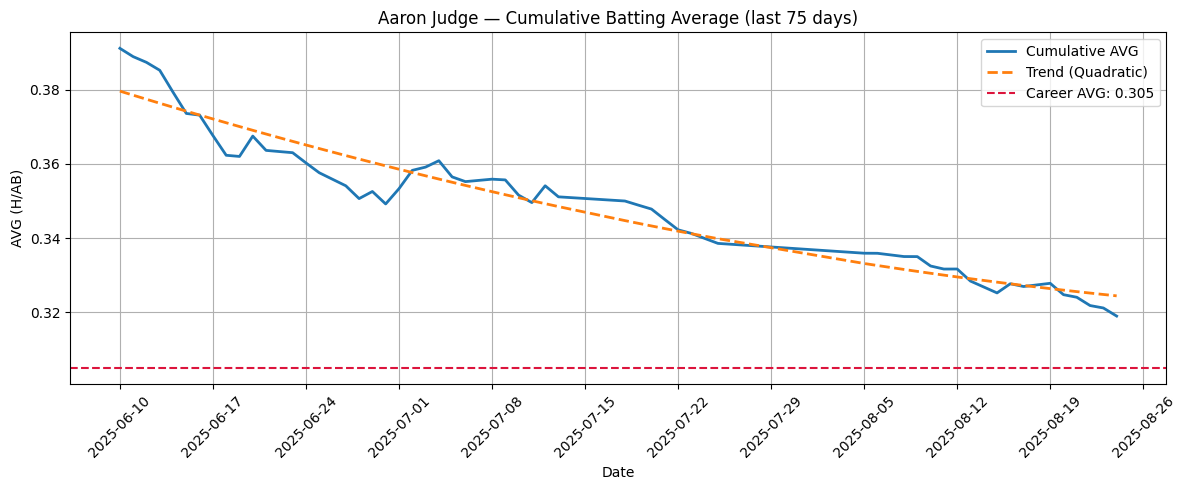

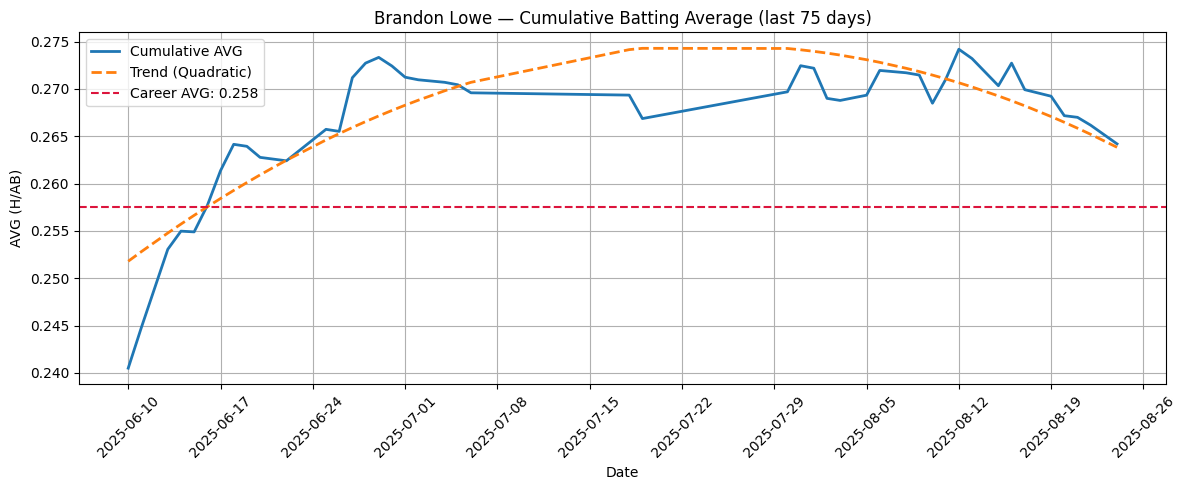

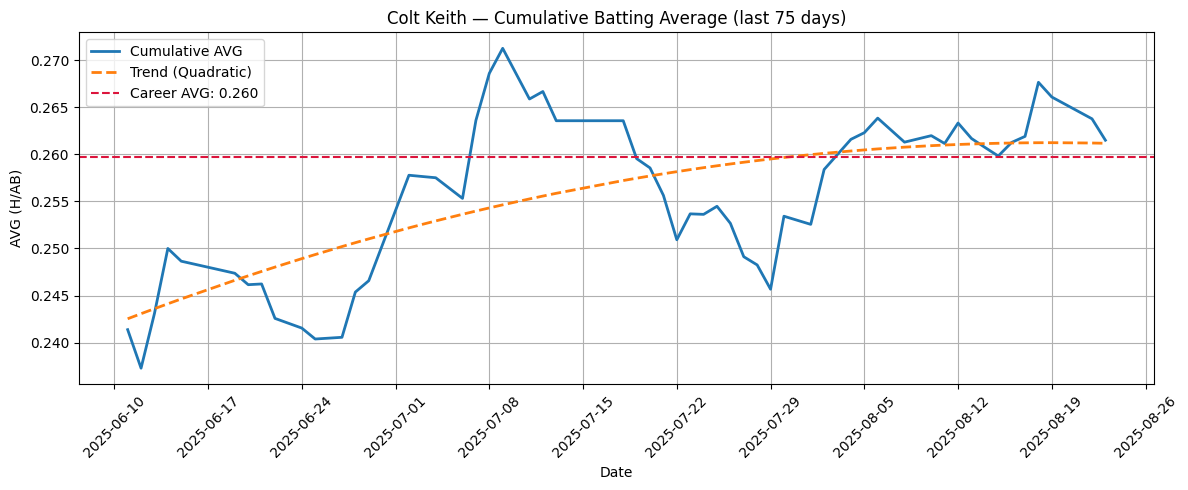

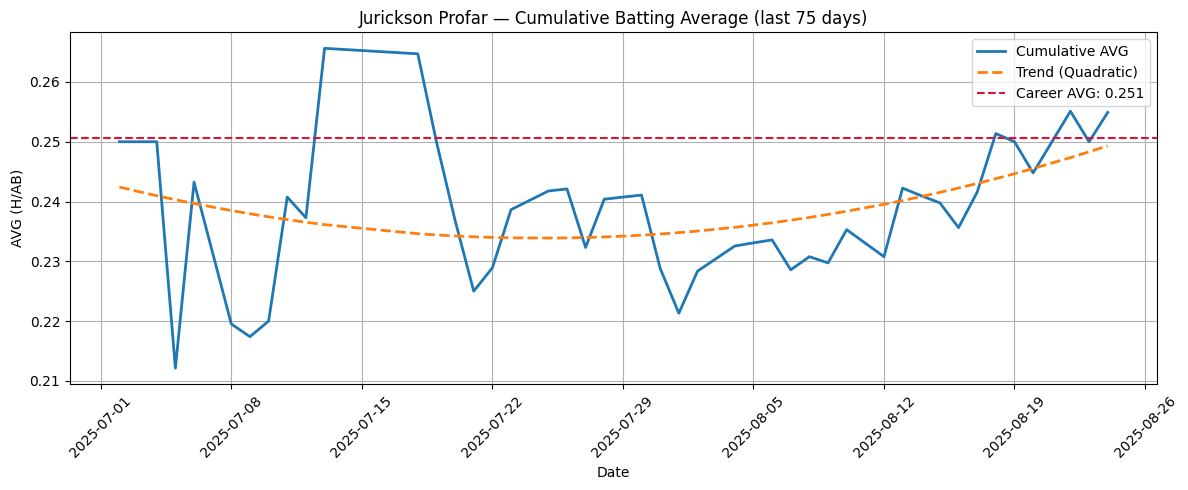

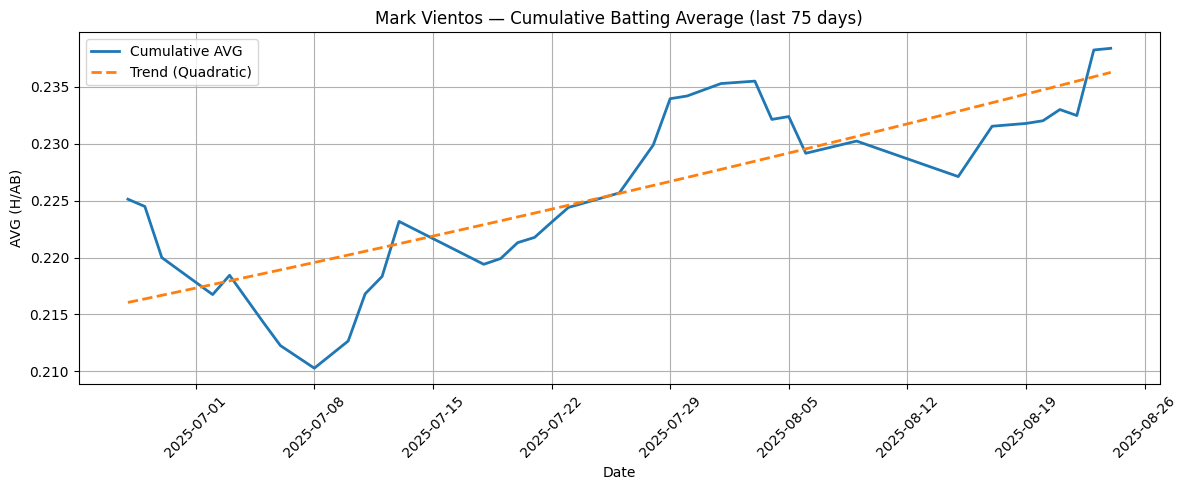

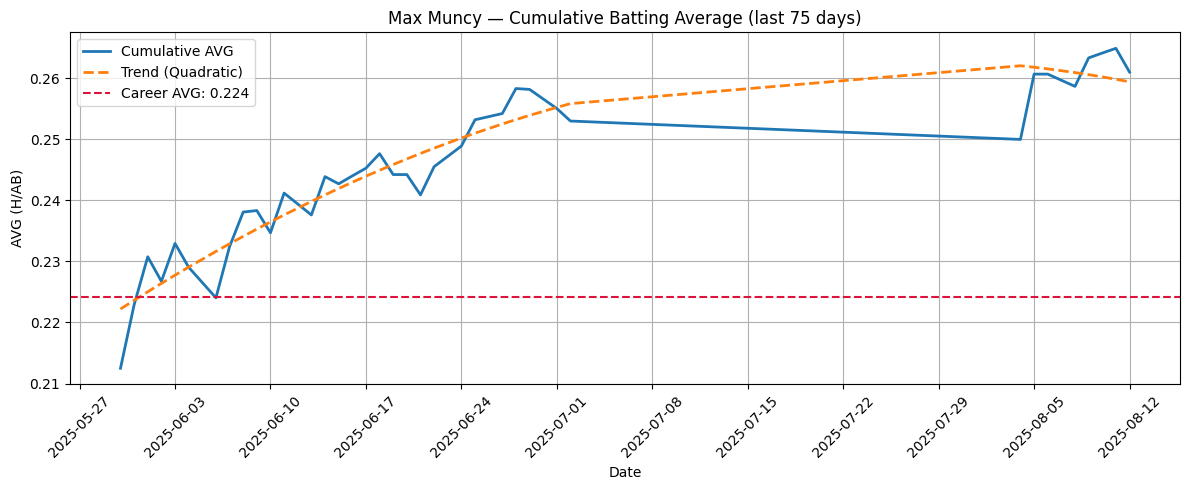

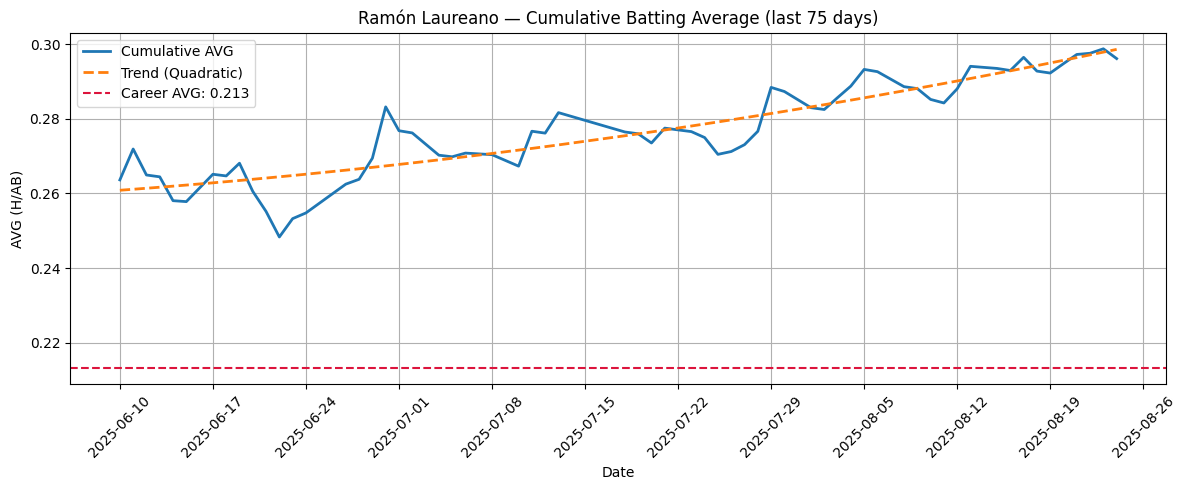

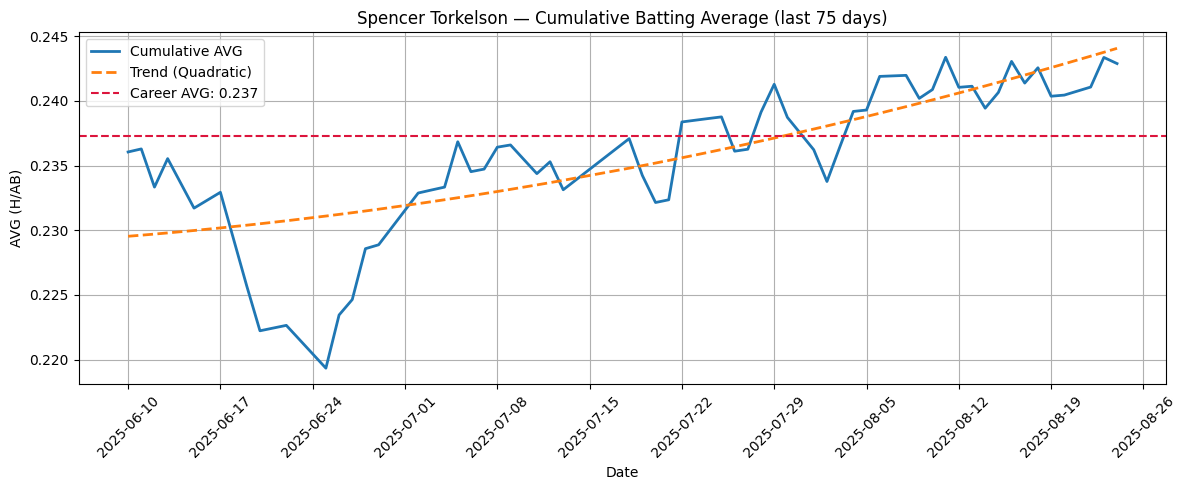

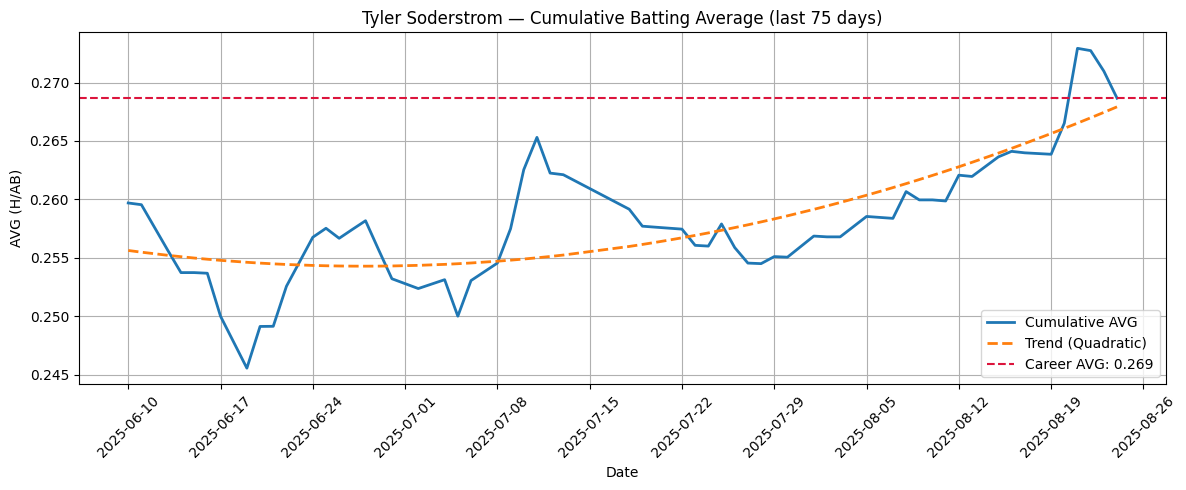

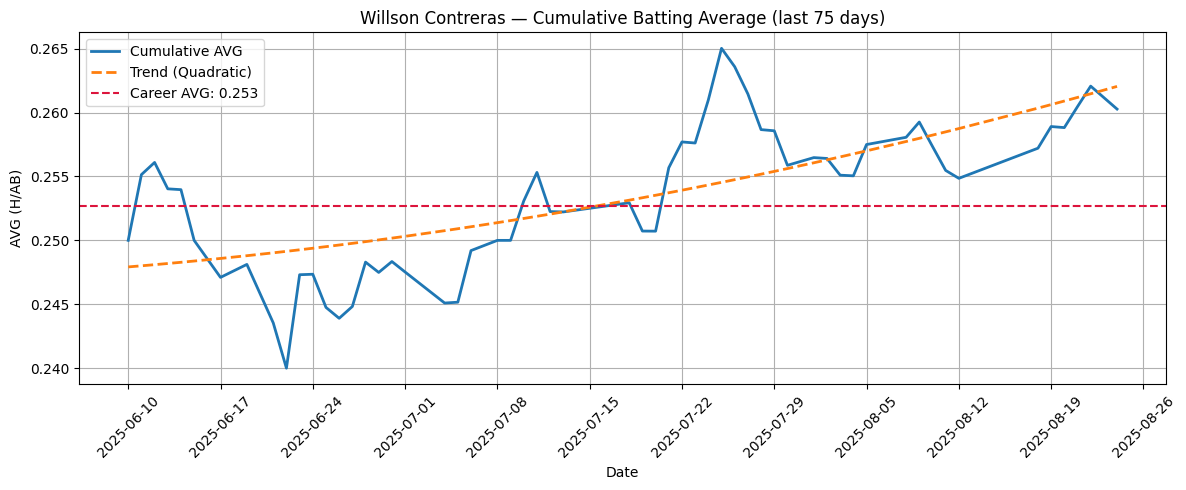

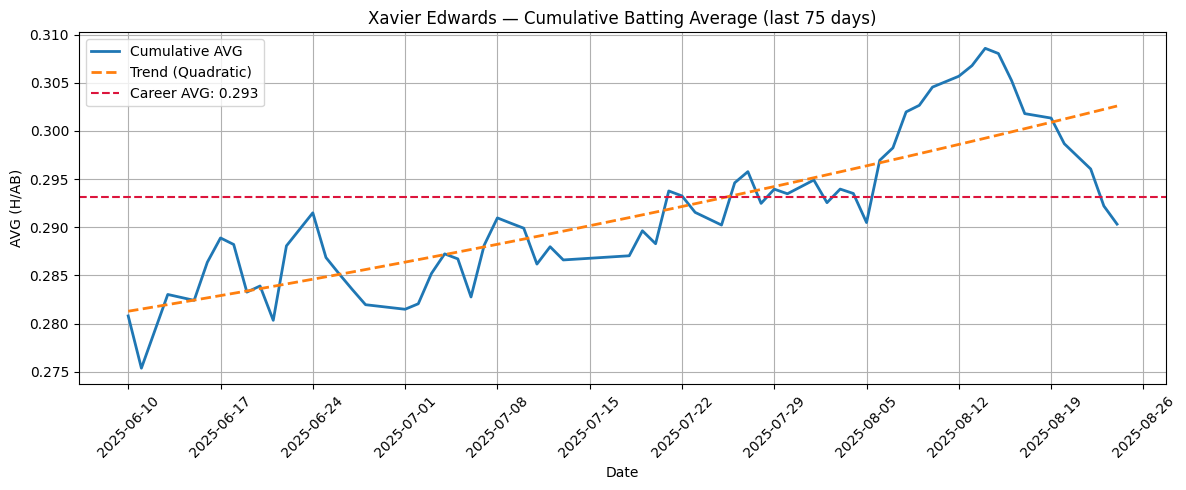

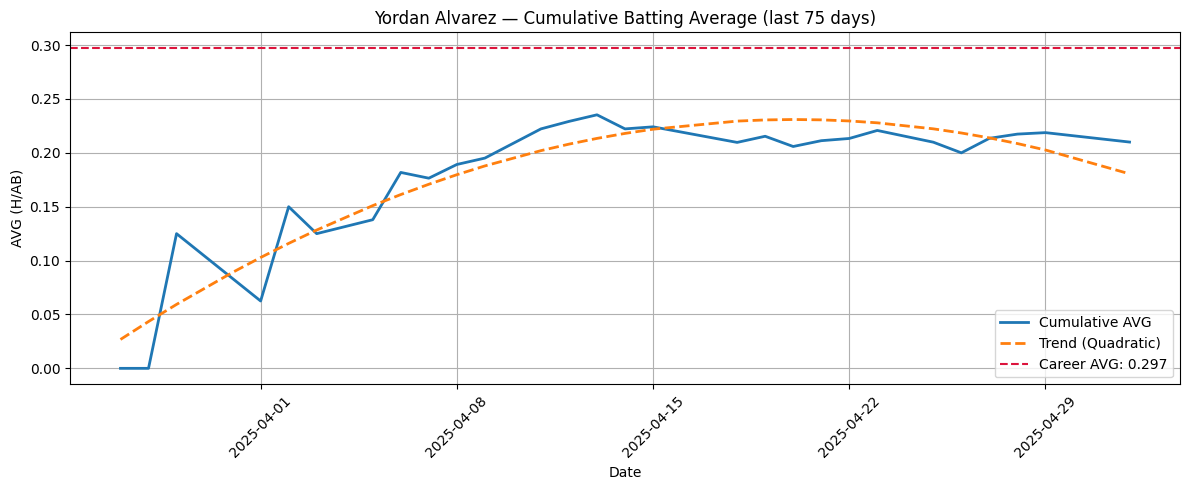

[Saved] PDF with all plots -> plots/roster_batting_plots.pdf
[Done] Plots generated. Season summary:
      player_name  PA  AB   H  TB  BB  HBP  SF  SH      AVG      OBP      SLG      OPS
 Tyler Soderstrom 524 469 126 222  48    5   2   0 0.268657 0.341603 0.473348 0.814951
Spencer Torkelson 523 457 111 220  52    9   5   0 0.242888 0.328872 0.481400 0.810272
   Xavier Edwards 511 465 135 169  40    1   2   3 0.290323 0.346457 0.363441 0.709898
      Aaron Judge 510 442 141 291  59    4   5   0 0.319005 0.400000 0.658371 1.058371
Willson Contreras 500 438 114 201  39   18   4   1 0.260274 0.342685 0.458904 0.801589
     Brandon Lowe 441 405 107 195  30    2   4   0 0.264198 0.315193 0.481481 0.796674
       Colt Keith 397 348  91 148  44    1   3   1 0.261494 0.343434 0.425287 0.768722
   Ramón Laureano 378 341 101 182  27    7   3   0 0.296188 0.357143 0.533724 0.890867
     Mark Vientos 349 323  77 133  20    2   4   0 0.238390 0.283668 0.411765 0.695432
        Max Muncy 337 272  71

In [7]:
if EXPORT_PDF and SAVE_PLOTS:
    os.makedirs(os.path.dirname(PDF_PATH), exist_ok=True)
    pdf = PdfPages(PDF_PATH)
else:
    pdf = None

for name, dfp in daily.groupby('player_name'):
    dfp = dfp.sort_values('game_date')
    if dfp.empty:
        continue
    cutoff = dfp['game_date'].max() - pd.Timedelta(days=DAYS_BACK_FOR_PLOT)
    df_plot = dfp[dfp['game_date'] >= cutoff]

    if len(df_plot) < 3:
        print(f"[Info] Skipping {name} (not enough recent games)")
        continue

    # Quadratic trend on cumulative AVG
    X = df_plot['game_date'].map(pd.Timestamp.toordinal).to_numpy().reshape(-1,1)
    y = df_plot['cum_AVG'].to_numpy()
    yhat = None
    if np.isfinite(y).sum() >= 3:
        poly = PolynomialFeatures(degree=2)
        Xp = poly.fit_transform(X)
        reg = LinearRegression().fit(Xp, y)
        yhat = reg.predict(Xp)

    # Plot
    fig = plt.figure(figsize=(12,5))
    ax = plt.gca()
    ax.plot(df_plot['game_date'], df_plot['cum_AVG'], linewidth=2, label='Cumulative AVG')

    if yhat is not None:
        ax.plot(df_plot['game_date'], yhat, linestyle='--', linewidth=2, label='Trend (Quadratic)')

    if USE_CAREER_AVG and name in career_avg_map and pd.notnull(career_avg_map[name]):
        ax.axhline(y=career_avg_map[name], linestyle='--', linewidth=1.5, color='crimson',
                   label=f'Career AVG: {career_avg_map[name]:.3f}')

    ax.set_title(f'{name} — Cumulative Batting Average (last {DAYS_BACK_FOR_PLOT} days)')
    ax.set_xlabel('Date')
    ax.set_ylabel('AVG (H/AB)')
    ax.legend()
    ax.grid(True)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Save and/or add to PDF
    if SAVE_PLOTS:
        safe_name = re.sub(r'[^a-zA-Z0-9_\-]+', '_', name.strip())
        out_path = os.path.join(PLOTS_DIR, f'{safe_name}_cumAVG.png')
        plt.savefig(out_path, dpi=150)

    if pdf is not None:
        pdf.savefig(fig)

    plt.show()
    plt.close(fig)

if pdf is not None:
    pdf.close()
    print(f"[Saved] PDF with all plots -> {PDF_PATH}")

print("[Done] Plots generated. Season summary:")
print(season.to_string(index=False))

Box Plots w/ Career Average

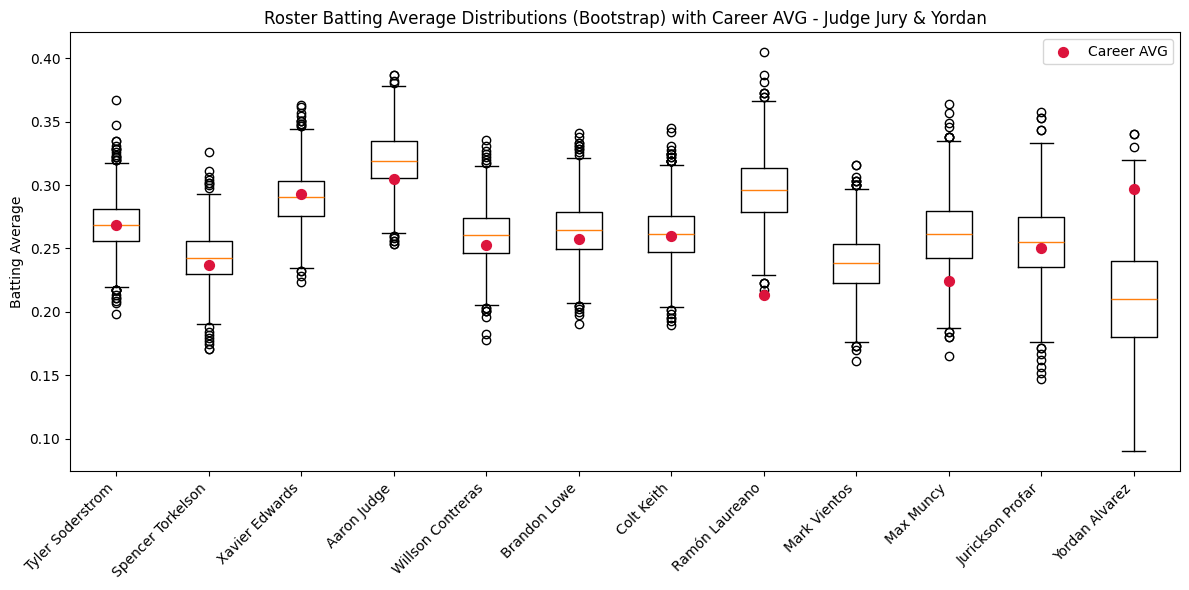

In [9]:
def plot_roster_ba_boxplot(season_roster, career_avg_map):
    """
    Boxplot of batting average distributions (bootstrap) for roster players,
    overlaying a dot for each player's career AVG.
    """
    players = season_roster['player_name'].astype(str).tolist()
    boot_dists = []
    rng = np.random.default_rng(42)

    # build bootstrap distributions
    for _, r in season_roster.iterrows():
        H, AB = int(r['H']), int(r['AB'])
        if AB <= 0:
            boot_dists.append(np.array([np.nan]))
            continue
        outcomes = np.concatenate([np.ones(H), np.zeros(AB - H)])
        avgs = rng.choice(outcomes, size=(2000, AB), replace=True).mean(axis=1)
        boot_dists.append(avgs)

    fig, ax = plt.subplots(figsize=(12,6))
    ax.boxplot(boot_dists, tick_labels=players, showmeans=False)

    # overlay career avg as a dot
    for i, name in enumerate(players, start=1):
        if name in career_avg_map:
            ax.scatter(i, career_avg_map[name], 
                       color="crimson", marker="o", s=50, zorder=3,
                       label="Career AVG" if i == 1 else None)  # add legend only once

    ax.set_xticklabels(players, rotation=45, ha='right')
    ax.set_ylabel("Batting Average")
    ax.set_title(f"Roster Batting Average Distributions (Bootstrap) with Career AVG - {team_name}")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

plot_roster_ba_boxplot(season,career_avg_map)

Machine Learning

In [11]:
import pandas as pd
import numpy as np

# Ensure sorted by player/date
daily = daily.sort_values(["player_name", "game_date"]).copy()

# ---- Future 14-day label (hits/AB in the next 14 games) ----
future_k = 14
daily["future_hits_14"] = (
    daily.groupby("player_name")["H"]
         .shift(-1)                      # exclude today's game from the future window
         .rolling(future_k, min_periods=5).sum()
)
daily["future_ab_14"] = (
    daily.groupby("player_name")["AB"]
         .shift(-1)
         .rolling(future_k, min_periods=5).sum()
)
daily["future_avg_14"] = daily["future_hits_14"] / daily["future_ab_14"]

In [12]:
# 1) sort first
daily = daily.sort_values(["player_name", "game_date"]).reset_index(drop=True)

# 2) rolling past form (ALIGNED via transform)
daily["past_hits_7"]  = daily.groupby("player_name")["H"].transform(lambda s: s.rolling(7,  min_periods=3).sum())
daily["past_ab_7"]    = daily.groupby("player_name")["AB"].transform(lambda s: s.rolling(7,  min_periods=3).sum())
daily["past_hits_14"] = daily.groupby("player_name")["H"].transform(lambda s: s.rolling(14, min_periods=5).sum())
daily["past_ab_14"]   = daily.groupby("player_name")["AB"].transform(lambda s: s.rolling(14, min_periods=5).sum())
daily["past_hits_30"] = daily.groupby("player_name")["H"].transform(lambda s: s.rolling(30, min_periods=8).sum())
daily["past_ab_30"]   = daily.groupby("player_name")["AB"].transform(lambda s: s.rolling(30, min_periods=8).sum())

daily["past_avg_7"]  = daily["past_hits_7"]  / daily["past_ab_7"]
daily["past_avg_14"] = daily["past_hits_14"] / daily["past_ab_14"]
daily["past_avg_30"] = daily["past_hits_30"] / daily["past_ab_30"]

# If you prefer groupby().rolling(), always drop the extra level:
# daily["past_hits_7"] = (
#     daily.groupby("player_name")["H"]
#          .rolling(7, min_periods=3).sum()
#          .reset_index(level=0, drop=True)
# )

# 3) cumulative per player (ALIGNED via groupby().cumsum())
daily["cum_H"]   = daily.groupby("player_name")["H"].cumsum()
daily["cum_BB"]  = daily.groupby("player_name")["BB"].cumsum()
daily["cum_HBP"] = daily.groupby("player_name")["HBP"].cumsum()
daily["cum_AB"]  = daily.groupby("player_name")["AB"].cumsum()
daily["cum_SF"]  = daily.groupby("player_name")["SF"].cumsum()
daily["cum_TB"]  = daily.groupby("player_name")["TB"].cumsum()

daily["cum_OBP"] = (daily["cum_H"] + daily["cum_BB"] + daily["cum_HBP"]) / (
    daily["cum_AB"] + daily["cum_BB"] + daily["cum_HBP"] + daily["cum_SF"]
)
daily["cum_SLG"] = daily["cum_TB"] / daily["cum_AB"].replace(0, np.nan)

# 4) optional plate discipline (use transform to keep index aligned)
if {"SO","PA"}.issubset(daily.columns):
    daily["K_pct"]  = np.where(daily["PA"] > 0, daily["SO"]/daily["PA"], np.nan)
    daily["BB_pct"] = np.where(daily["PA"] > 0, daily["BB"]/daily["PA"], np.nan)
    daily["past_kpct_14"]  = daily.groupby("player_name")["K_pct"].transform(lambda s: s.rolling(14, min_periods=5).mean())
    daily["past_bbpct_14"] = daily.groupby("player_name")["BB_pct"].transform(lambda s: s.rolling(14, min_periods=5).mean())

# 5) future label (still aligned because shift happens inside each group)
daily["future_hits_14"] = daily.groupby("player_name")["H"].transform(lambda s: s.shift(-1).rolling(14, min_periods=5).sum())
daily["future_ab_14"]   = daily.groupby("player_name")["AB"].transform(lambda s: s.shift(-1).rolling(14, min_periods=5).sum())
daily["future_avg_14"]  = daily["future_hits_14"] / daily["future_ab_14"]

# pick your feature columns
feat_cols = ["past_avg_7", "past_avg_14", "cum_OBP", "cum_SLG"]

# keep only rows with no NaNs in features/target
dfm = daily.dropna(subset=feat_cols + ["future_avg_14"]).copy()

In [13]:
# 1. Define features/target again (if not already in memory)
feat_cols = ["past_avg_7","past_avg_14","cum_OBP","cum_SLG","H","AB","BB"]
X = daily[feat_cols].fillna(0)
y = daily["future_avg_14"].fillna(0)   # <-- if you built next-14-day avg target

# 2. Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [14]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# --- Train models ---
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42))
ridge.fit(X_train, y_train)

# --- Evaluate models on test set (print R2, MSE, RMSE) ---
y_pred_rf    = rf.predict(X_test)
y_pred_gb    = gb.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

def eval_model(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)   # sklearn 1.6+: always MSE
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:<6} R² = {r2:.3f}   MSE = {mse:.6f}   RMSE = {rmse:.4f}")

eval_model("RF",    y_test, y_pred_rf)
eval_model("GB",    y_test, y_pred_gb)
eval_model("Ridge", y_test, y_pred_ridge)

import pandas as pd

# --- 1) helper to extract names from your roster object ---
def extract_roster_names(roster_like):
    if isinstance(roster_like, list):
        if len(roster_like) and isinstance(roster_like[0], dict):
            return [d.get("player_name") or d.get("name") for d in roster_like if (d.get("player_name") or d.get("name"))]
        return [str(x) for x in roster_like]
    if isinstance(roster_like, pd.DataFrame):
        col = "player_name" if "player_name" in roster_like.columns else ("name" if "name" in roster_like.columns else None)
        if col is None:
            raise ValueError("Roster DataFrame must have a 'player_name' or 'name' column.")
        return roster_like[col].dropna().astype(str).tolist()
    if isinstance(roster_like, dict):
        n = roster_like.get("player_name") or roster_like.get("name")
        return [n] if n else []
    return [str(roster_like)]

# --- 2) build roster_names from your `roster` variable ---
roster_names = extract_roster_names(roster)

# --- 3) latest feature row per player from your modeling frame `dfm` ---
latest_rows = (
    dfm.sort_values(["player_name", "game_date"])
       .groupby("player_name")
       .tail(1)
       .set_index("player_name")
)

# --- 4) ensure columns align with training (X_train) and filter to roster ---
feature_cols = list(X_train.columns) if hasattr(X_train, "columns") else feat_cols
pred_rows = latest_rows.loc[latest_rows.index.intersection(roster_names), feature_cols].copy()

if pred_rows.empty:
    raise ValueError("None of the roster names matched dfm players. Check name formats/casing.")

# --- 5) predict with trained models rf/gb/ridge ---
pred_rf    = rf.predict(pred_rows)
pred_gb    = gb.predict(pred_rows)
pred_ridge = ridge.predict(pred_rows)

forecast = (
    pd.DataFrame({
        "Player": pred_rows.index,
        "RF_pred_next14_AVG":    pred_rf,
        "GB_pred_next14_AVG":    pred_gb,
        "RG_pred_next14_AVG": pred_ridge
    })
    .sort_values("RF_pred_next14_AVG", ascending=False)
    .reset_index(drop=True)
)

print("\n--- Roster Forecasts (Next 14-Day AVG) ---")
print(forecast)

RF     R² = 0.893   MSE = 0.000609   RMSE = 0.0247
GB     R² = 0.901   MSE = 0.000560   RMSE = 0.0237
Ridge  R² = 0.901   MSE = 0.000562   RMSE = 0.0237

--- Roster Forecasts (Next 14-Day AVG) ---
               Player  RF_pred_next14_AVG  GB_pred_next14_AVG  \
0      Ramón Laureano            0.360510            0.340327   
1    Tyler Soderstrom            0.349602            0.340351   
2    Jurickson Profar            0.316908            0.308379   
3           Max Muncy            0.312487            0.319927   
4   Willson Contreras            0.297636            0.295963   
5   Spencer Torkelson            0.260786            0.267389   
6        Mark Vientos            0.257568            0.259817   
7          Colt Keith            0.243906            0.255934   
8      Xavier Edwards            0.234683            0.227243   
9        Brandon Lowe            0.208991            0.211890   
10        Aaron Judge            0.192672            0.196353   
11     Yordan Alvarez  

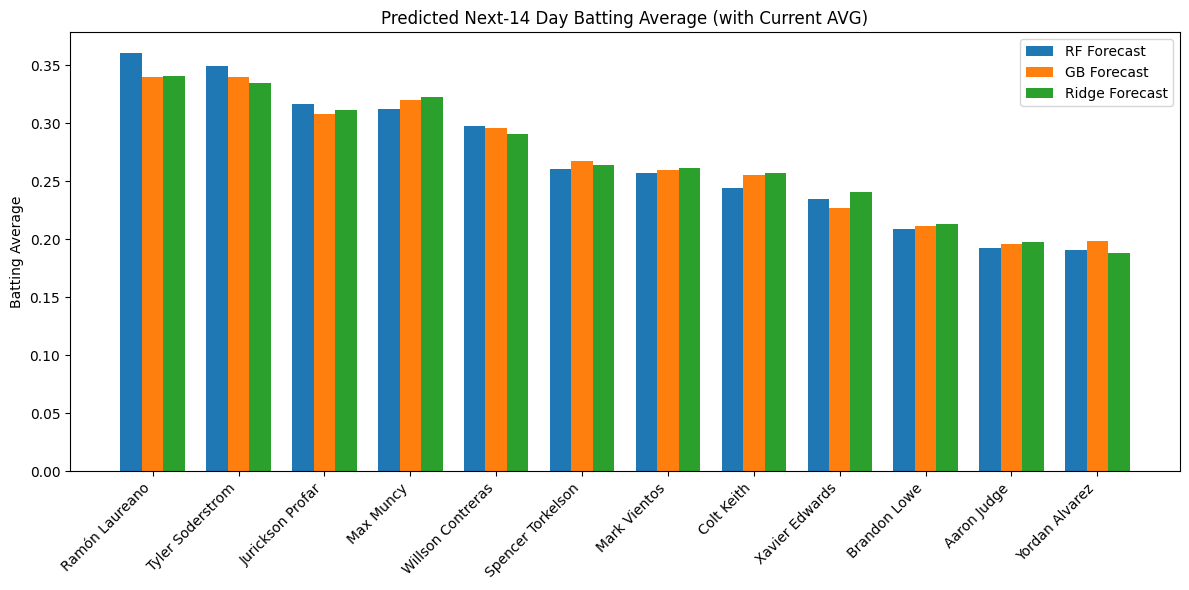

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_forecast_with_current(forecast, dfm):
    """
    forecast : DataFrame with predictions (columns: Player, RF_pred_next14_AVG, GB_pred_next14_AVG, Ridge_pred_next14_AVG)
    dfm      : full modeling frame containing latest 'AVG' per player
    """
    # grab most recent AVG per player
    latest_avg = (
        dfm.sort_values(["player_name", "game_date"])
           .groupby("player_name")['AVG']
           .tail(1)
    )

    # align with forecast players
    forecast = forecast.copy()
    forecast["Current_AVG"] = forecast["Player"].map(latest_avg)

    # --- plotting ---
    fig, ax = plt.subplots(figsize=(12,6))

    x = range(len(forecast))
    bar_width = 0.25

    ax.bar([i - bar_width for i in x], forecast["RF_pred_next14_AVG"], 
           width=bar_width, label="RF Forecast")
    ax.bar(x, forecast["GB_pred_next14_AVG"], 
           width=bar_width, label="GB Forecast")
    ax.bar([i + bar_width for i in x], forecast["RG_pred_next14_AVG"], 
           width=bar_width, label="Ridge Forecast")

    # overlay current AVG as black dots
    #ax.scatter(x, forecast["Current_AVG"], color="black", s=60, zorder=5, label="Current AVG")

    ax.set_xticks(x)
    ax.set_xticklabels(forecast["Player"], rotation=45, ha="right")
    ax.set_ylabel("Batting Average")
    ax.set_title("Predicted Next-14 Day Batting Average (with Current AVG)")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Example call
plot_forecast_with_current(forecast, dfm)